In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:


print("Current Directory:")
print(os.getcwd())

print("\nFiles/Folders:")
print(os.listdir())

Current Directory:
c:\Gayatri\Prodigy\PRODIGY_ML_03

Files/Folders:
['.git', '.gitignore', 'PetImages', 'PRODIGY_ML_03.ipynb', 'README.md', 'SVM_Screenshots']


In [3]:

print("PetImages exists:", os.path.exists("PetImages"))
print("Cat exists:", os.path.exists("PetImages/Cat"))
print("Dog exists:", os.path.exists("PetImages/Dog"))

print("\nNumber of Cat Images:", len(os.listdir("PetImages/Cat")))
print("Number of Dog Images:", len(os.listdir("PetImages/Dog")))

PetImages exists: True
Cat exists: True
Dog exists: True

Number of Cat Images: 12501
Number of Dog Images: 12501


In [4]:
dataset_path = "PetImages" 
cat_path = os.path.join(dataset_path, "Cat")
dog_path = os.path.join(dataset_path, "Dog") 
print("Cats:", len(os.listdir(cat_path))) 
print("Dogs:", len(os.listdir(dog_path)))

Cats: 12501
Dogs: 12501


In [5]:
X = []
y = []

MAX_IMAGES_PER_CLASS = 500

In [6]:
count = 0

for img_name in os.listdir(cat_path):

    if count >= MAX_IMAGES_PER_CLASS:
        break

    img_path = os.path.join(cat_path, img_name)

    try:

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (64, 64))

        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )

        X.append(features)
        y.append(0)

        count += 1

    except:
        pass

print("Loaded Cat Images:", count)

Loaded Cat Images: 500


Loading Dog Images

In [7]:
count = 0

for img_name in os.listdir(dog_path):

    if count >= MAX_IMAGES_PER_CLASS:
        break

    img_path = os.path.join(dog_path, img_name)

    try:

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (64, 64))

        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )

        X.append(features)
        y.append(1)

        count += 1

    except:
        pass

print("Loaded Dog Images:", count)

Loaded Dog Images: 500


In [8]:
print("Total Samples:", len(X))
print("Feature Length:", len(X[0]))
print(set(len(item) for item in X))

Total Samples: 1000
Feature Length: 1764
{1764}


In [9]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 1764)
y shape: (1000,)


Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Training

In [11]:
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    random_state=42
)

svm.fit(X_train, y_train)

print("Training Complete!")

Training Complete!


Accuracy

In [12]:
y_pred = svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 69.0 %


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.64      0.67       100
           1       0.67      0.74      0.70       100

    accuracy                           0.69       200
   macro avg       0.69      0.69      0.69       200
weighted avg       0.69      0.69      0.69       200



Dataset Distribution

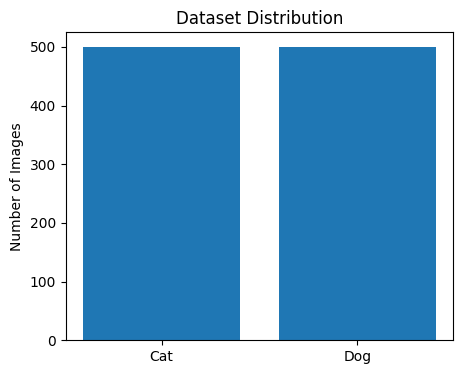

In [14]:
plt.figure(figsize=(5,4))

plt.bar(
    ["Cat", "Dog"],
    [MAX_IMAGES_PER_CLASS, MAX_IMAGES_PER_CLASS]
)

plt.title("Dataset Distribution")
plt.ylabel("Number of Images")

plt.savefig("SVM_Screenshots/dataset_distribution.png")

plt.show()

Confusion Matrix

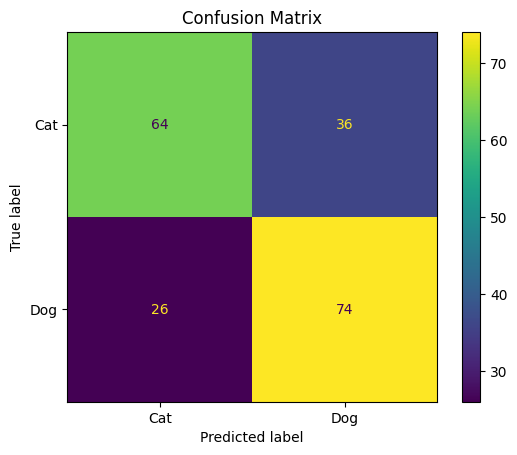

In [15]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot()

plt.title("Confusion Matrix")

plt.savefig("SVM_Screenshots/Confusion_Matrix.png")

plt.show()

Model Performance

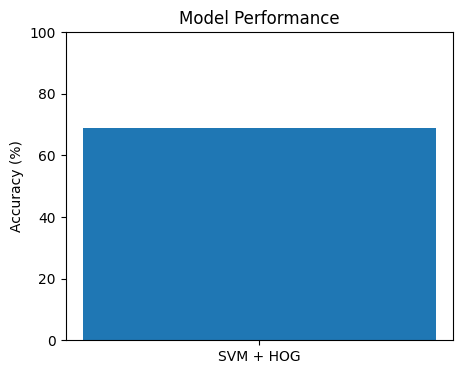

In [16]:
plt.figure(figsize=(5,4))

plt.bar(["SVM + HOG"], [accuracy * 100])

plt.ylim(0,100)

plt.ylabel("Accuracy (%)")

plt.title("Model Performance")

plt.savefig("SVM_Screenshots/Model_Performance.png")

plt.show()

Classification Result

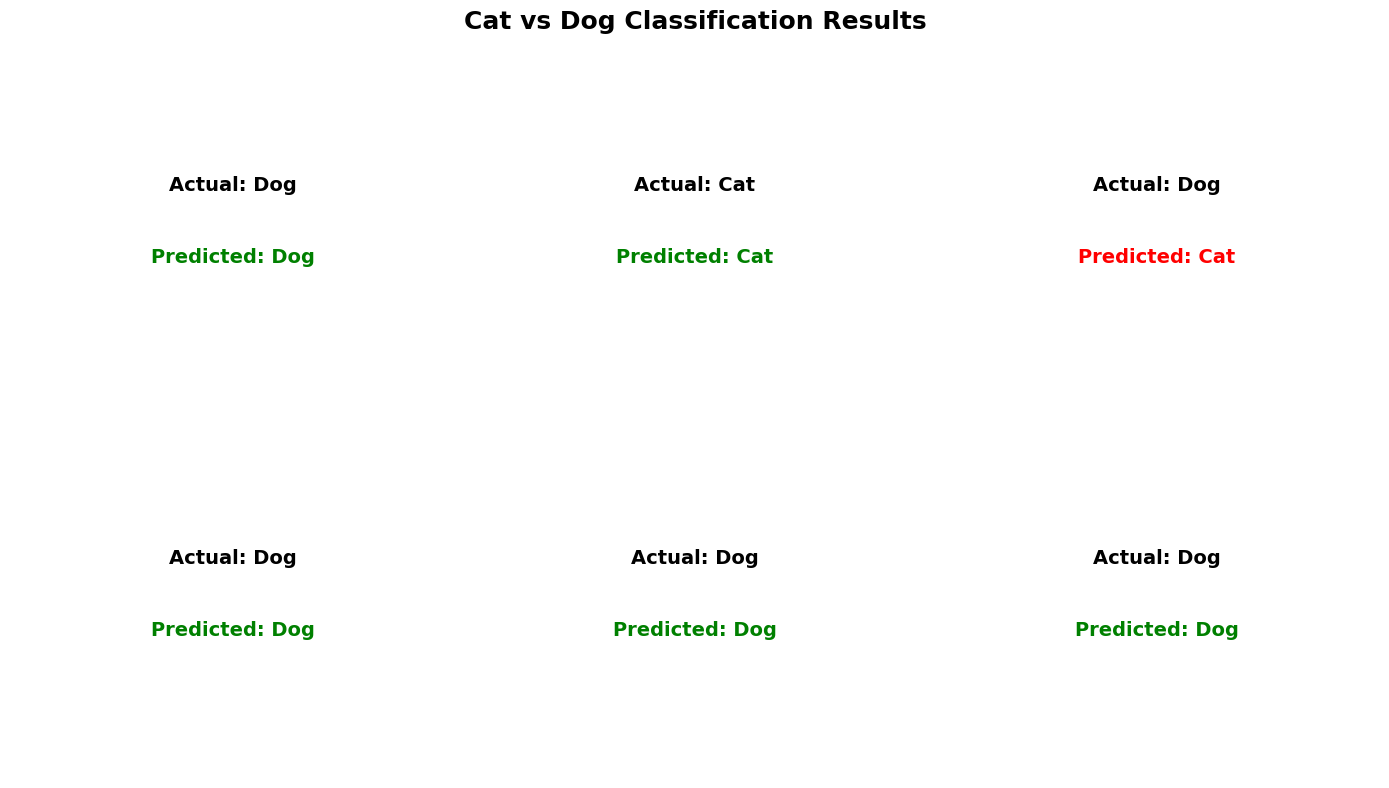

In [17]:
import random

indices = random.sample(range(len(X_test)), 6)

plt.figure(figsize=(14,8))

for i, idx in enumerate(indices):

    actual = "Dog" if y_test[idx] == 1 else "Cat"
    predicted = "Dog" if y_pred[idx] == 1 else "Cat"

    color = "green" if actual == predicted else "red"

    plt.subplot(2,3,i+1)

    plt.text(
        0.5,
        0.6,
        f"Actual: {actual}",
        fontsize=14,
        ha='center',
        fontweight='bold'
    )

    plt.text(
        0.5,
        0.4,
        f"Predicted: {predicted}",
        fontsize=14,
        ha='center',
        color=color,
        fontweight='bold'
    )

    plt.axis('off')

plt.suptitle(
    "Cat vs Dog Classification Results",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig("SVM_Screenshots/Classification_Result.png")

plt.show()

In [18]:
import pickle

with open("svm_cat_dog_model.pkl", "wb") as file:
    pickle.dump(svm, file)

print("Model Saved Successfully!")

Model Saved Successfully!


Prediction

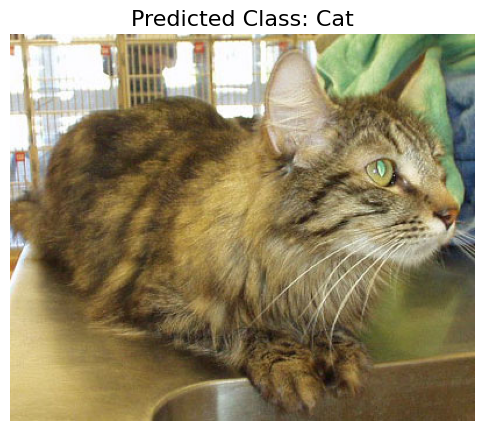

In [19]:
import random

test_image = random.choice(os.listdir(cat_path))

image_path = os.path.join(cat_path, test_image)

img = cv2.imread(image_path)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = cv2.resize(gray, (64,64))

features = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    block_norm='L2-Hys'
)

prediction = svm.predict([features])

label = "Dog" if prediction[0] == 1 else "Cat"

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Predicted Class: {label}", fontsize=16)
plt.axis("off")
plt.show()